In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp
import deepxde as dde
dde.backend.set_default_backend("pytorch")

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "pytorch". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


In [2]:
rho = 1
mu = 1
u_in = 1
D = 1
L = 2

In [3]:
geom = dde.geometry.Rectangle(xmin=[-L/2, -D/2], xmax=[L/2, D/2])

In [4]:
def boundary_wall(X, on_boundary):
    return on_boundary and (
        np.isclose(X[1], -D/2, rtol=1e-5, atol=1e-8) or
        np.isclose(X[1],  D/2, rtol=1e-5, atol=1e-8)
    )

def boundary_inlet(X, on_boundary):
    return on_boundary and np.isclose(X[0], -L/2, rtol=1e-5, atol=1e-8)

def boundary_outlet(X, on_boundary):
    return on_boundary and np.isclose(X[0], L/2, rtol=1e-5, atol=1e-8)

In [5]:
bc_wall_u = dde.DirichletBC(geom, lambda X:0., boundary_wall, component= 0)
bc_wall_v = dde.DirichletBC(geom, lambda X:0., boundary_wall, component= 1)

bc_inlet_u = dde.DirichletBC(geom, lambda X:u_in, boundary_inlet, component= 0)
bc_inlet_v = dde.DirichletBC(geom, lambda X:0.   , boundary_inlet, component= 1)

bc_outlet_p = dde.DirichletBC(geom, lambda X:0.  , boundary_outlet, component= 2)
bc_outlet_v = dde.DirichletBC(geom, lambda X:0.  , boundary_outlet, component= 1)

In [6]:
def pde(X,Y):
    du_x =dde.grad.jacobian(Y, X, i=0, j=0)
    du_y =dde.grad.jacobian(Y, X, i=0, j=1)
    dv_x =dde.grad.jacobian(Y, X, i=1, j=0)
    dv_y =dde.grad.jacobian(Y, X, i=1, j=1)
    dp_x =dde.grad.jacobian(Y, X, i=2, j=0)
    dp_y =dde.grad.jacobian(Y, X, i=2, j=1)
    
    du_xx = dde.grad.hessian(Y, X, component=0, i=0, j=0)
    du_yy = dde.grad.hessian(Y, X, component=0, i=1, j=1)
    dv_xx = dde.grad.hessian(Y, X, component=1, i=0, j=0)
    dv_yy = dde.grad.hessian(Y, X, component=1, i=1, j=1)

    u = Y[:, 0].reshape(-1, 1)
    v = Y[:, 1].reshape(-1, 1)
    
    pde_u = u * du_x + v * du_y + (1/rho) * dp_x - (mu/rho) * (du_xx + du_yy)
    pde_v = u * dv_x + v * dv_y + (1/rho) * dp_y - (mu/rho) * (dv_xx + dv_yy)
    pde_cont = du_x + dv_y
    
    return [pde_u,pde_v,pde_cont]

In [7]:
data = dde.data.PDE(geom,
                   pde,
                   [bc_wall_u,bc_wall_v,bc_inlet_u,bc_inlet_v,bc_outlet_p,bc_outlet_v],
                   num_domain  = 2000,
                   num_boundary= 200,
                   num_test = 200)

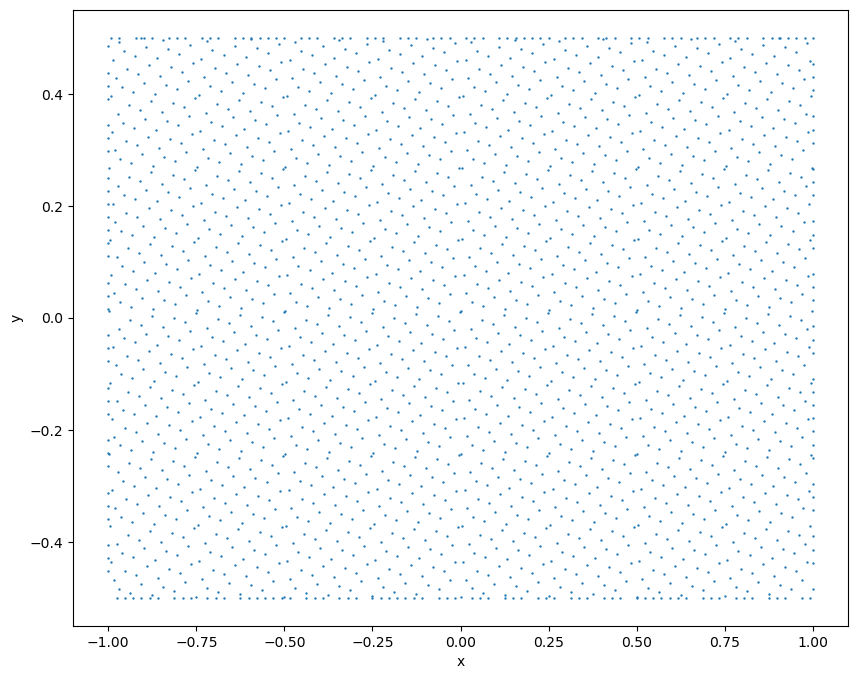

In [8]:
plt.figure(figsize=(10,8))
plt.scatter(data.train_x_all[:,0], data.train_x_all[:,1], s= 0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [9]:
net = dde.maps.FNN([2] + [64]*5 + [3] , "tanh", "Glorot uniform")

In [10]:
model = dde.Model(data, net)
model.compile("adam",lr=1e-3)

Compiling model...
'compile' took 0.001196 s



In [11]:
losshistory, train_state = model.train(epochs = 10000)

Training model...

Step      Train loss                                                                                    Test loss                                                                                     Test metric
0         [1.57e-02, 1.11e-01, 7.65e-04, 1.59e-02, 2.57e-02, 1.26e+00, 6.71e-02, 7.66e-03, 6.63e-02]    [1.36e-02, 1.13e-01, 6.54e-04, 1.59e-02, 2.57e-02, 1.26e+00, 6.71e-02, 7.66e-03, 6.63e-02]    []  
1000      [8.77e-04, 6.73e-04, 8.95e-03, 2.92e-02, 1.42e-02, 3.76e-02, 2.78e-03, 6.80e-04, 1.65e-05]    [5.48e-04, 3.90e-04, 5.27e-03, 2.92e-02, 1.42e-02, 3.76e-02, 2.78e-03, 6.80e-04, 1.65e-05]    []  
2000      [8.31e-04, 7.54e-04, 4.80e-03, 2.33e-02, 1.04e-02, 3.23e-02, 5.49e-04, 2.83e-04, 2.16e-05]    [5.32e-04, 4.47e-04, 2.50e-03, 2.33e-02, 1.04e-02, 3.23e-02, 5.49e-04, 2.83e-04, 2.16e-05]    []  
3000      [9.35e-03, 8.41e-04, 3.08e-03, 1.97e-02, 8.69e-03, 2.66e-02, 1.19e-03, 2.44e-03, 5.62e-05]    [9.42e-03, 6.07e-04, 1.55e-03, 1.97e-02, 8.69e-03, 2.66e-0

In [12]:
dde.optimizers.config.set_LBFGS_options(maxiter= 3000)
model.compile("L-BFGS")
losshistory, train_state = model.train()
dde.saveplot(losshistory, train_state, issave=False, isplot=False)

Compiling model...
'compile' took 0.002538 s

Training model...

Step      Train loss                                                                                    Test loss                                                                                     Test metric
10000     [2.76e-02, 8.02e-03, 2.33e-03, 1.48e-02, 4.74e-03, 1.42e-02, 5.22e-03, 2.33e-03, 1.14e-04]    [2.07e-02, 6.93e-03, 1.06e-03, 1.48e-02, 4.74e-03, 1.42e-02, 5.22e-03, 2.33e-03, 1.14e-04]    []  
11000     [4.14e-04, 5.89e-04, 7.63e-04, 5.97e-03, 1.26e-03, 5.35e-03, 2.06e-03, 2.20e-05, 6.28e-06]    [2.37e-04, 3.43e-04, 4.09e-04, 5.97e-03, 1.26e-03, 5.35e-03, 2.06e-03, 2.20e-05, 6.28e-06]    []  
12000     [3.55e-04, 3.97e-04, 4.64e-04, 4.12e-03, 8.89e-04, 3.80e-03, 9.37e-04, 1.15e-05, 1.17e-06]    [2.32e-04, 2.30e-04, 1.63e-04, 4.12e-03, 8.89e-04, 3.80e-03, 9.37e-04, 1.15e-05, 1.17e-06]    []  
13000     [3.49e-04, 4.09e-04, 5.56e-04, 2.91e-03, 6.84e-04, 3.02e-03, 5.56e-04, 7.74e-06, 2.02e-06]    [1.41e-04, 2

Saving loss history to /Users/erfantaatizadeh/Documents/Physics Informed NN/PINNS/loss.dat ...
Saving training data to /Users/erfantaatizadeh/Documents/Physics Informed NN/PINNS/train.dat ...
Saving test data to /Users/erfantaatizadeh/Documents/Physics Informed NN/PINNS/test.dat ...


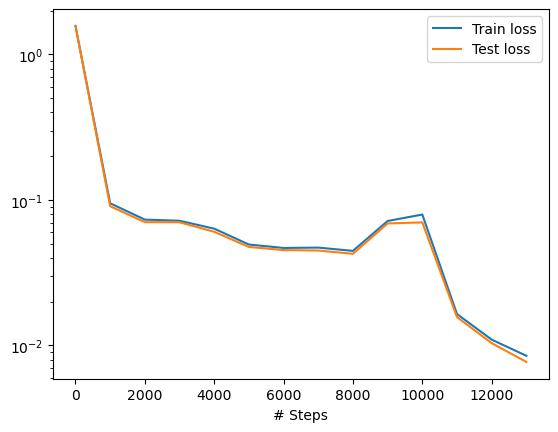

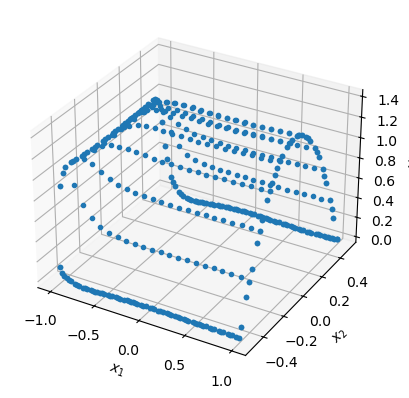

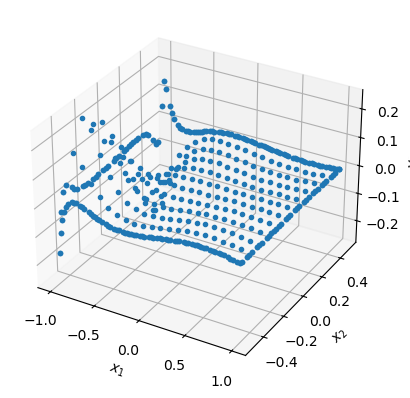

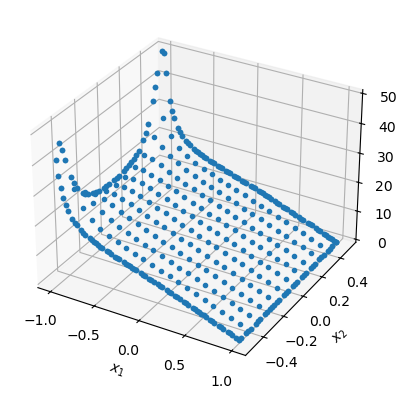

In [13]:
dde.saveplot(losshistory,train_state, issave= True, isplot=True)

In [14]:
samples = geom.random_points(500000)
result = model.predict(samples)

Interpolating velocity field for streamlines...


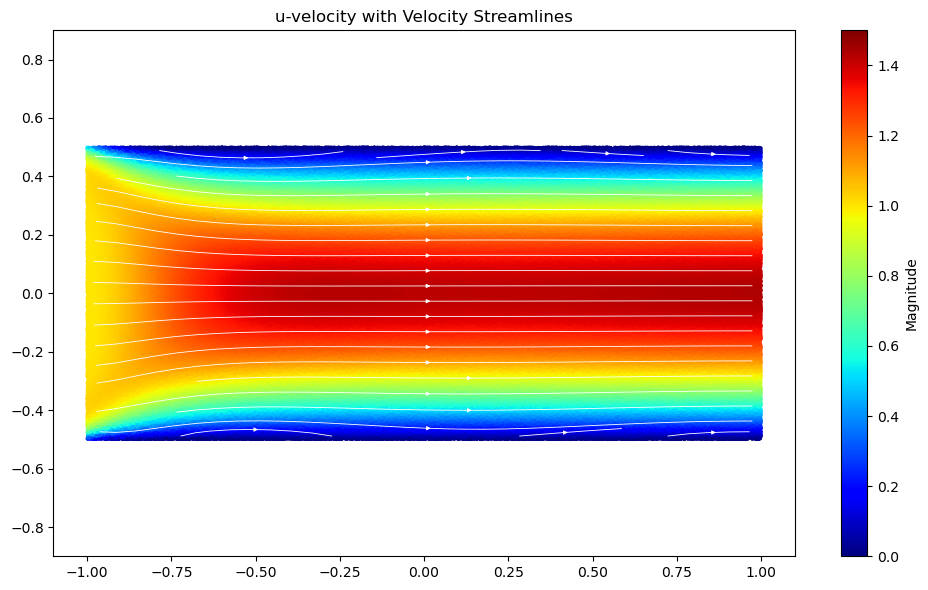

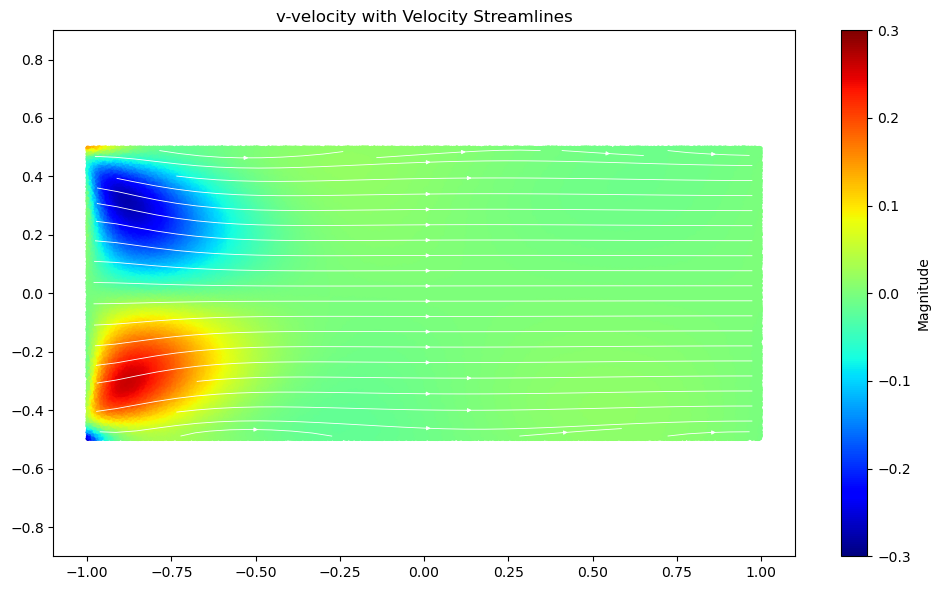

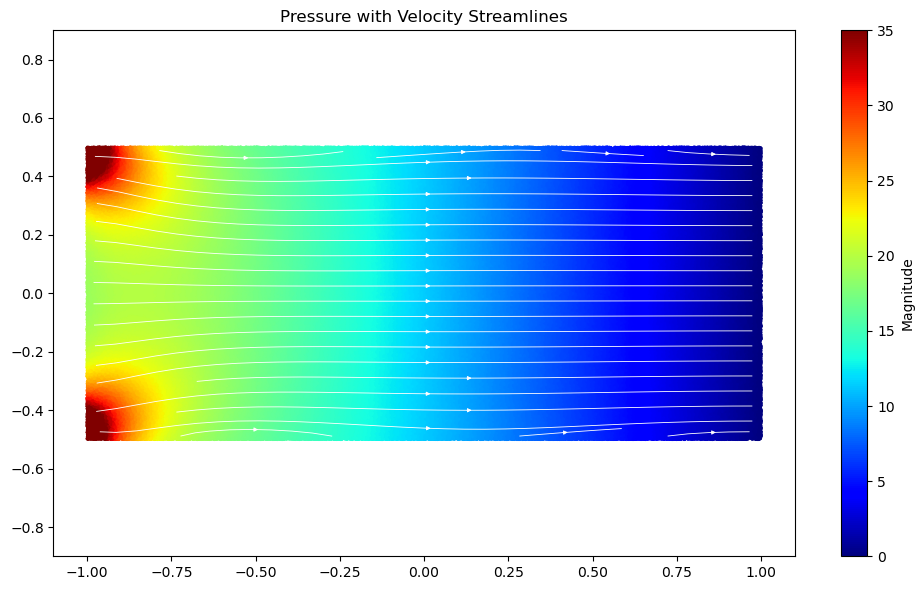

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

# ==========================================
# 1. Pre-compute Grid for Streamlines
# ==========================================
# Define a regular grid covering the domain
grid_x = np.linspace(-1.1, 1.1, 200)
grid_y = np.linspace(-0.9, 0.9, 200)
GridX, GridY = np.meshgrid(grid_x, grid_y)

# Interpolate U and V velocity components onto this grid
# Assuming result[:, 0] is u-velocity and result[:, 1] is v-velocity
print("Interpolating velocity field for streamlines...")
grid_u = griddata(samples, result[:, 0], (GridX, GridY), method='linear')
grid_v = griddata(samples, result[:, 1], (GridX, GridY), method='linear')

# ==========================================
# 2. Plotting Loop with Streamlines
# ==========================================
color_legend = [[0, 1.5], [-0.3, 0.3], [0, 35]]
field_names = ["u-velocity", "v-velocity", "Pressure"]

for idx in range(3):
    plt.figure(figsize=(10, 6))
    
    # A. The Scalar Field (Color Background)
    plt.scatter(samples[:, 0],
                samples[:, 1],
                c=result[:, idx],
                cmap='jet',
                s=2)
    plt.colorbar(label='Magnitude')
    plt.clim(color_legend[idx])
    
    # B. The Streamlines (Velocity Vector Field)
    # Overlay streamlines on top of the scatter plot
    # color='k' (black) or 'w' (white) usually contrasts best with 'jet'
    plt.streamplot(GridX, GridY, grid_u, grid_v, 
                   color='white', 
                   linewidth=0.6, 
                   arrowsize=0.6, 
                   density=1.2) # Adjust density (higher = more lines)
    
    # C. Limits & Layout
    plt.xlim(-1.1, 1.1)
    plt.ylim(-0.9, 0.9)
    plt.title(f"{field_names[idx]} with Velocity Streamlines")
    plt.tight_layout()
    plt.show()

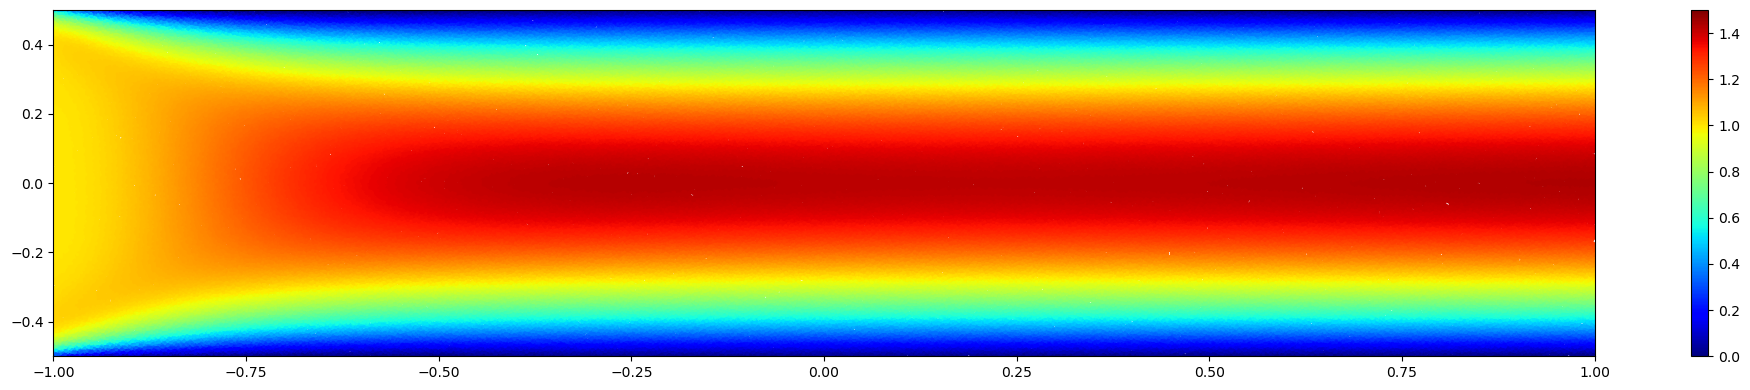

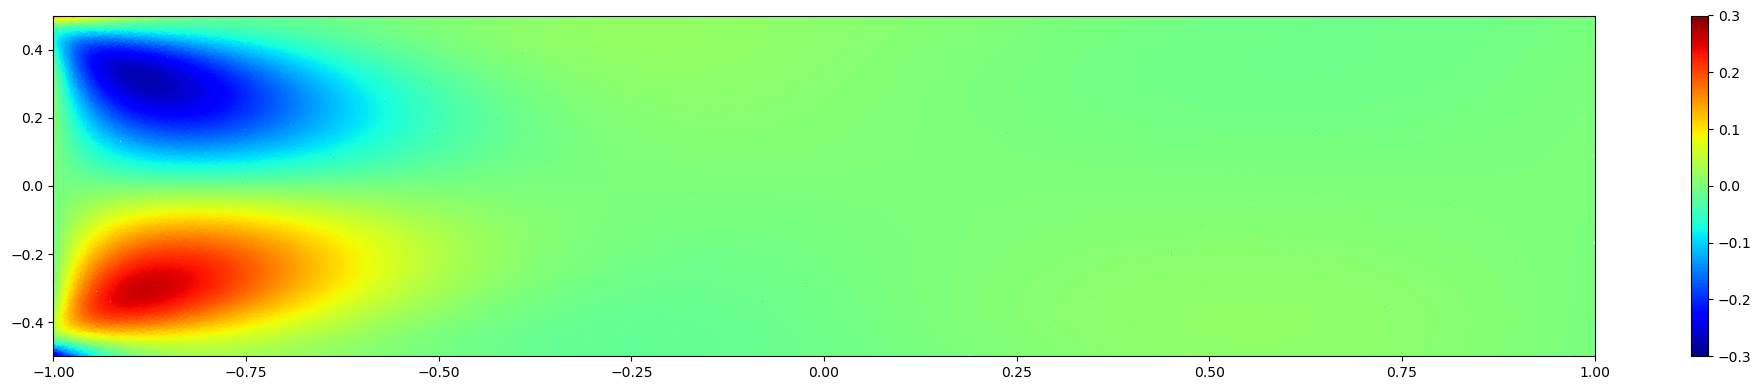

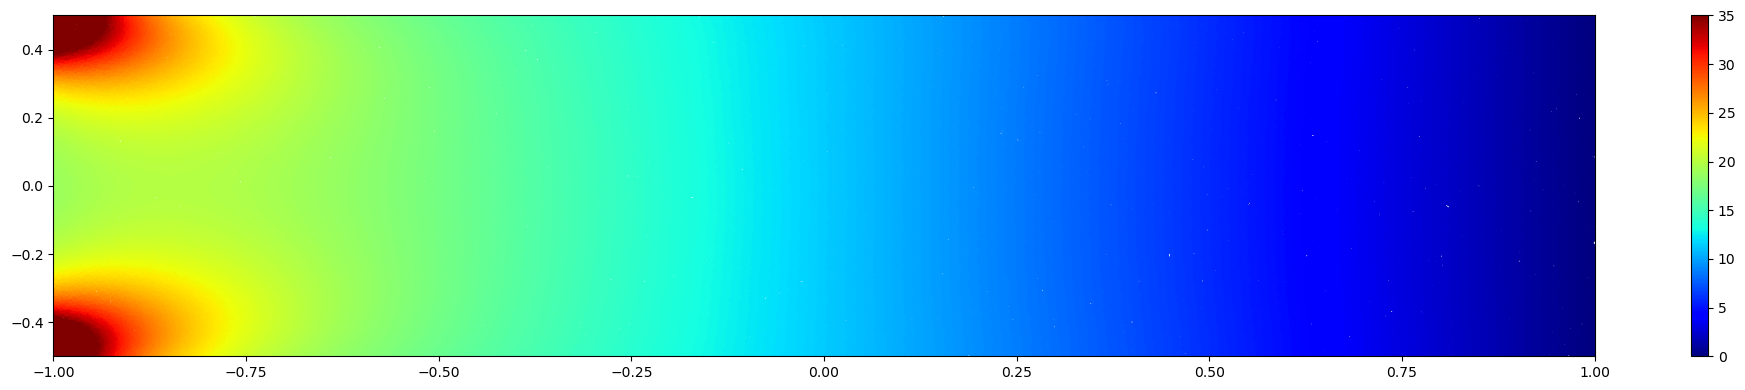

In [16]:
color_legend = [[0,1.5],[-0.3,0.3],[0,35]]

for idx in range(3):
    plt.figure(figsize=(20,4))
    plt.scatter(samples[:,0],
               samples[:,1],
               c = result[:,idx],
               cmap= 'jet',
               s=2)
    plt.colorbar()
    plt.clim(color_legend[idx])
    plt.xlim((0-L/2, L-L/2))
    plt.ylim((0-D/2, D-D/2))
    plt.tight_layout()
    plt.show()

In [31]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ==========================================
# 1. Geometry & Physics Constants (FIXED)
# ==========================================
# Geometry dimensions based on your DeepXDE setup (L=2, D=1)
X_INLET  = -1.0   # Inlet x-coordinate (-L/2)
X_OUTLET =  1.0   # Outlet x-coordinate (L/2)
Y_BOTTOM = -0.5   # Bottom wall y-coordinate (-D/2)
Y_TOP    =  0.5   # Top wall y-coordinate (D/2)

# Physics Properties (Update these if you have specific numbers)
FLUID_RHO = 1.0       # Fluid Density
FLUID_MU  = 1.0       # Fluid Viscosity
PARTICLE_D = 0.01     # Particle Diameter
PARTICLE_RHO = 10.0   # Particle Density

# Derived Constants
PARTICLE_A = np.pi * (PARTICLE_D / 2)**2
PARTICLE_MASS = PARTICLE_RHO * (4/3) * np.pi * (PARTICLE_D / 2)**3

In [32]:
# ==========================================
# 2. Physics Helper Functions
# ==========================================
def get_drag_coefficient(Re):
    """
    Calculates Drag Coefficient (Cd) using Schiller-Naumann correlation.
    """
    if Re <= 0: return 0.0
    if Re < 1000:
        return (24.0 / Re) * (1 + 0.15 * (Re**0.687))
    return 0.44

def particle_momentum_eq(t, state, model):
    """
    Lagrangian Particle Momentum Equation (Drag Only).
    state = [x, y, u_p, v_p]
    """
    xp, yp, up, vp = state
    
    # 1. Query DeepXDE Model for Fluid Velocity at particle position
    pos_tensor = np.array([[xp, yp]])
    fluid_vars = model.predict(pos_tensor) # Returns [u, v, p]
    ug = fluid_vars[0, 0]
    vg = fluid_vars[0, 1]
    
    # 2. Calculate Relative Velocity
    u_rel = ug - up
    v_rel = vg - vp
    v_rel_mag = np.sqrt(u_rel**2 + v_rel**2)
    
    # 3. Calculate Particle Reynolds Number
    Re_p = (FLUID_RHO * v_rel_mag * PARTICLE_D) / FLUID_MU
    
    # 4. Calculate Drag Force & Acceleration
    Cd = get_drag_coefficient(Re_p)
    
    # Acceleration = Force / Mass
    coeff = (0.5 * Cd * PARTICLE_A * FLUID_RHO * v_rel_mag) / PARTICLE_MASS
    
    ax = coeff * u_rel
    ay = coeff * v_rel
    
    return [up, vp, ax, ay]

In [33]:
# ==========================================
# 3. Tracing & Plotting Function (Updated)
# ==========================================

def outlet_event(t, state, model):
    """
    Event function for solve_ivp. 
    Returns 0 when the particle reaches the outlet (X_OUTLET).
    """
    # state[0] is x position. 
    # We want to find the root of (x - X_OUTLET) = 0
    return state[0] - X_OUTLET

# Set event flags
outlet_event.terminal = True  # Stop the integration when this event occurs
outlet_event.direction = 1    # Trigger only when crossing from left to right

def trace_and_plot_particles(model, n_particles=10, t_max=10.0):
    print(f"Releasing {n_particles} particles from x={X_INLET}...")
    
    plt.figure(figsize=(10, 5))
    
    # Plot Domain Boundaries
    plt.plot([X_INLET, X_OUTLET], [Y_BOTTOM, Y_BOTTOM], 'k-', linewidth=2) 
    plt.plot([X_INLET, X_OUTLET], [Y_TOP, Y_TOP], 'k-', linewidth=2)       
    plt.plot([X_INLET, X_INLET], [Y_BOTTOM, Y_TOP], 'k--', alpha=0.5, label='Inlet')
    plt.axvline(x=X_OUTLET, color='k', linestyle='--', alpha=0.5, label='Outlet')

    start_y_positions = np.linspace(Y_BOTTOM + 0.05, Y_TOP - 0.05, n_particles)
    
    for i, y0 in enumerate(start_y_positions):
        init_state = [X_INLET, y0, 0.0, 0.0]
        
        # Solve ODE with 'events' argument
        sol = solve_ivp(
            fun=particle_momentum_eq,
            t_span=[0, t_max],
            y0=init_state,
            args=(model,),
            events=outlet_event,  # <--- This stops the solver at X=1
            rtol=1e-4, 
            atol=1e-6,
            dense_output=True
        )
        
        x_vals = sol.y[0]
        y_vals = sol.y[1]
        
        # Plot trajectory
        plt.plot(x_vals, y_vals, '-', alpha=0.8)
        plt.scatter(x_vals[0], y_vals[0], c='green', s=15, zorder=3) 
        
        # Mark where it stopped (the outlet)
        if sol.status == 1: # 1 means a termination event occurred
            plt.scatter(x_vals[-1], y_vals[-1], c='red', s=15, zorder=3)

    plt.title(f"Particle Tracing (Stops at Outlet x={X_OUTLET})")
    plt.xlabel("x")
    plt.ylabel("y")
    
    # Strict axis limits to hide any minor numerical overshoot
    plt.xlim(X_INLET - 0.1, X_OUTLET + 0.1)
    plt.ylim(Y_BOTTOM - 0.1, Y_TOP + 0.1)
    
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

Releasing 30 particles from x=-1.0...


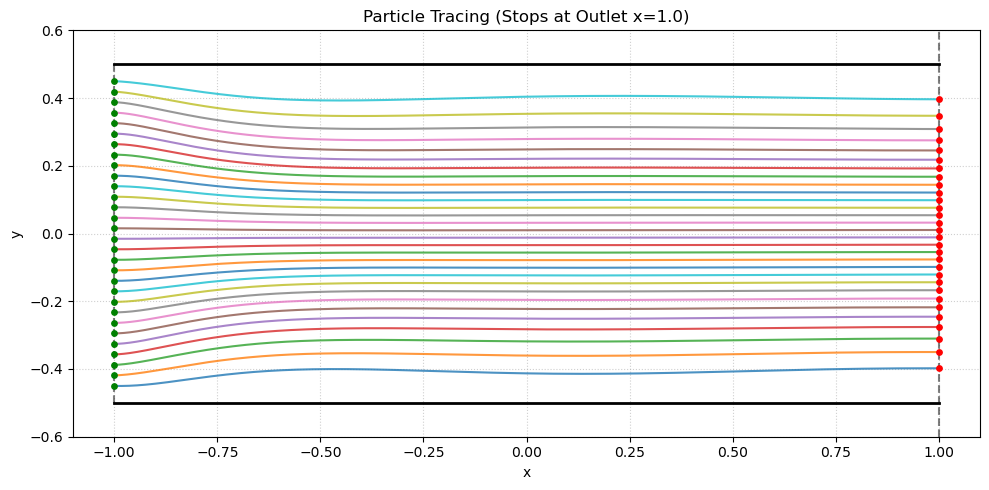

In [38]:
# Run it
trace_and_plot_particles(model, n_particles=30)